### What is a linear function?

A function that can be represented by a straight line on a graph. A polynomial of degree 1.

A linear function with one variable is written as:

$$f(x) = ax + b$$

Where $a$ is the **slope** and $b$ is the **intercept**.

In [1]:
!pip install -q numpy pandas matplotlib ipywidgets


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
df = pd.read_csv("data.csv")
df.head()

,km,price
0,240000,3650
1,139800,3800
2,150500,4400
3,185530,4450
4,176000,5250


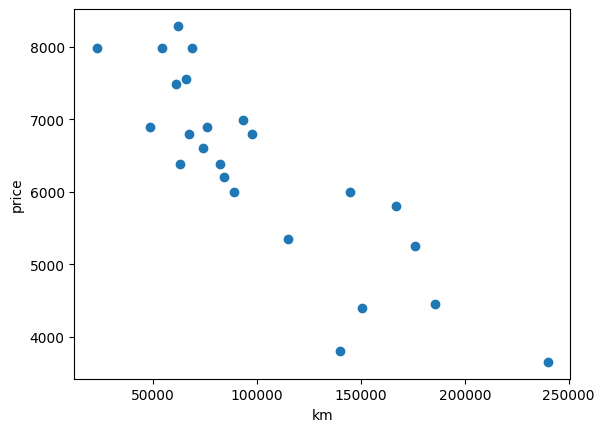

In [5]:
x = df['km']
y = df['price']

plt.scatter(x, y)
plt.xlabel("km")
plt.ylabel("price")
plt.show()

### Linear Regression

Linear regression finds the best-fit line for a dataset by minimizing the error between predicted values and actual values.

Given our data, can we find values of $a$ and $b$ such that $\hat{y} = ax + b$ approximates the relationship between km and price? Let's try adjusting them manually.

In [27]:
from ipywidgets import interact, FloatSlider
from IPython.display import display

def plot_line(a, b):
    x_line = np.linspace(x.min(), x.max(), 100)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(x, y, label="data")
    ax.plot(x_line, a * x_line + b, color="red", label=f"y = {a:.3f}x + {b:.0f}")
    ax.set_xlabel("km")
    ax.set_ylabel("price")
    ax.legend()
    display(fig)
    plt.close(fig)

interact(
    plot_line,
    a=FloatSlider(value=-0.03, min=-1, max=1, step=0.001, description="a"),
    b=FloatSlider(value=9700, min=-10000, max=50000, step=100, description="b"),
)

interactive(children=(FloatSlider(value=-0.03, description='a', max=1.0, min=-1.0, step=0.001), FloatSlider(va…

<function __main__.plot_line(a, b)>

### Cost Function: Mean Squared Error (MSE)

The error is measured using a **cost function**. In this case we use **MSE** (Mean Squared Error), which is the average squared difference between predicted values and actual values (residuals).

$$MSE = \frac{1}{n} \sum_{i=0}^{n} (y_i - \hat{y}_i)^2$$

Where:
- $y_i$ is the actual value
- $\hat{y}_i = ax_i + b$ is the predicted value
- $n$ is the number of data points

Lower MSE implies better accuracy. Let's calculate MSE for $a = -0.03$ and $b = 9700$.

In [23]:
a = -0.03
b = 9700

y_hat = a * x + b
mse = np.mean((y - y_hat) ** 2)

print(f"MSE for a={a}, b={b}: {mse:.2f}")

MSE for a=-0.03, b=9700: 753086.07


In [25]:
a_bad = 1
b_bad = 1

y_hat_bad = a_bad * x + b_bad
mse_bad = np.mean((y - y_hat_bad) ** 2)

print(f"MSE for a={a_bad}, b={b_bad}: {mse_bad:.2f}")

MSE for a=1, b=1: 11749501157.17


As we can see, the MSE for $a=1, b=1$ is massively higher than for $a=-0.03, b=9700$. This confirms that our manually adjusted line is a much better fit.

But how do we find the **optimal** $a$ and $b$ that minimize MSE? Trying values by hand is not practical. We need an algorithm that systematically finds the best parameters.

This is where **Gradient Descent** comes in.

### Gradient Descent

Gradient descent is an optimization algorithm that iteratively adjusts parameters to minimize a cost function. The idea is simple:

1. Start with random values for $a$ and $b$
2. Compute the **gradient** (partial derivatives) of the MSE with respect to $a$ and $b$ — this tells us the direction in which the error increases
3. Update $a$ and $b$ by moving in the **opposite** direction of the gradient
4. Repeat until convergence

$$a = a - \alpha \frac{\partial MSE}{\partial a}, \quad b = b - \alpha \frac{\partial MSE}{\partial b}$$

Where $\alpha$ is the **learning rate**, a small step size that controls how fast we move.